In [ ]:
# Import necessary libraries
import pandas as pd
import gdown

# Google Drive file ID for 'loan_data_final.csv'
file_id = "1C_xYDL8OystINSyxQn0RFx90jgIFnIXP"

# Construct the download URL
download_url = f"https://drive.google.com/uc?id={file_id}"

# Step 1: Download the file
output_file = "loan_data final.csv"  # Local filename to save the file
gdown.download(download_url, output_file, quiet=False)

# Step 2: Load the dataset
loan_data = pd.read_csv(output_file)

# Step 3: Preview the first few rows of the dataset
print(loan_data.head())

Downloading...
From: https://drive.google.com/uc?id=1C_xYDL8OystINSyxQn0RFx90jgIFnIXP
To: /content/loan_data final.csv
100%|██████████| 3.29M/3.29M [00:00<00:00, 150MB/s]

   person_age person_gender  ... previous_loan_defaults_on_file  loan_status
0          22        female  ...                             No            1
1          21        female  ...                            Yes            0
2          25        female  ...                             No            1
3          23        female  ...                             No            1
4          24          male  ...                             No            1

[5 rows x 14 columns]


Shape of dataset: (45000, 14)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  i

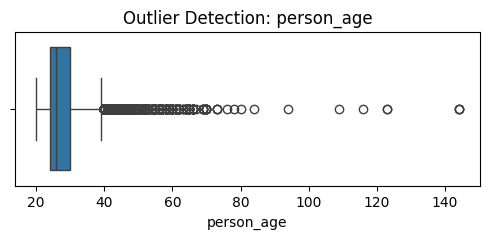

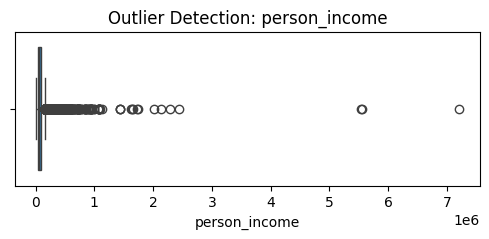

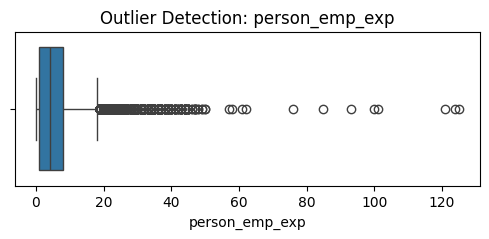

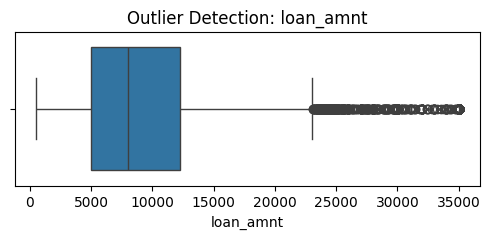

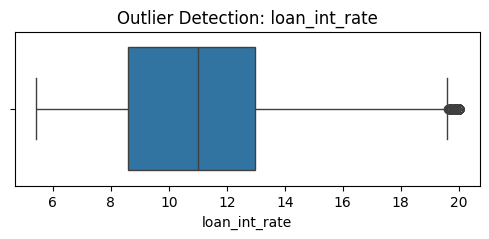

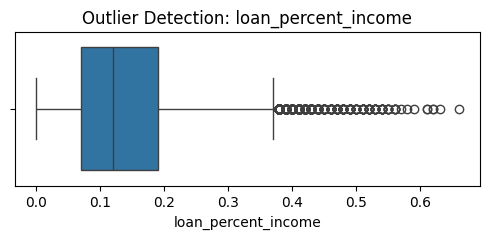

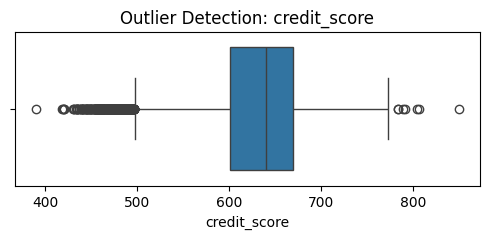


Final Dataset Shape: (42409, 23)

Final Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 42409 entries, 63 to 44999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      42409 non-null  int64  
 1   person_gender                   42409 non-null  int64  
 2   person_income                   42409 non-null  int64  
 3   person_emp_exp                  42409 non-null  int64  
 4   loan_amnt                       42409 non-null  int64  
 5   loan_int_rate                   42409 non-null  float64
 6   loan_percent_income             42409 non-null  float64
 7   cb_person_cred_hist_length      42409 non-null  int64  
 8   credit_score                    42409 non-null  int64  
 9   previous_loan_defaults_on_file  42409 non-null  int64  
 10  loan_status                     42409 non-null  int64  
 11  person_education_bachelor       42409 non-nul

In [ ]:
# =======================
# 1. Import Libraries
# =======================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =======================
# 2. Load Dataset
# =======================
df = pd.read_csv("loan_data final.csv")

# =======================
# 3. Initial Inspection
# =======================
print("Shape of dataset:", df.shape)
print("\nColumn Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# =======================
# 4. Handle Duplicates
# =======================
df = df.drop_duplicates()

# =======================
# 5. Standardize Categorical Data
# =======================
cat_cols = ['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
for col in cat_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

# Check unique values
for col in cat_cols:
    print(f"\nUnique values in {col}:", df[col].unique())

# =======================
# 6. Handle Missing Values
# =======================
# If any NA found, handle accordingly (here none, but check is included)
df = df.fillna({
    "person_age": df["person_age"].median(),
    "person_income": df["person_income"].median(),
    "person_emp_exp": df["person_emp_exp"].median(),
    "loan_amnt": df["loan_amnt"].median(),
    "loan_int_rate": df["loan_int_rate"].mean(),
    "credit_score": df["credit_score"].median()
})

# =======================
# 7. Outlier Detection & Treatment
# =======================
numeric_cols = ['person_age','person_income','person_emp_exp',
                'loan_amnt','loan_int_rate','loan_percent_income','credit_score']

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection: {col}")
    plt.show()

# Remove extreme outliers beyond 1st and 99th percentile
for col in ['person_income','loan_amnt','credit_score']:
    low, high = df[col].quantile([0.01, 0.99])
    df = df[(df[col] >= low) & (df[col] <= high)]

# =======================
# 8. Encode Categorical Variables
# =======================
# Binary encoding
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'yes':1,'no':0})
df['person_gender'] = df['person_gender'].map({'male':1,'female':0})

# One-hot encoding for multi-category vars
df = pd.get_dummies(df, columns=['person_education','person_home_ownership','loan_intent'], drop_first=True)

# =======================
# 9. Final Check
# =======================
print("\nFinal Dataset Shape:", df.shape)
print("\nFinal Data Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# =======================
# 10. Save Cleaned Dataset
# =======================
output_file = "Loan_Data_Final_Cleaned.csv"
df.to_csv(output_file, index=False)

print(f"✅ Cleaned dataset saved as: {output_file}")

In [ ]:
import pandas as pd
import numpy as np
import sklearn

# Load the cleaned dataset
df = pd.read_csv("Loan_Data_Final_Cleaned.csv")
print("Loaded shape:", df.shape)
print(df.head(3))


Loaded shape: (42409, 23)
   person_age  person_gender  ...  loan_intent_personal  loan_intent_venture
0          25              0  ...                 False                False
1          22              1  ...                 False                False
2          23              0  ...                 False                False

[3 rows x 23 columns]


brings table into memory so we can work with it; quick preview confirms we loaded the right file.

In [ ]:
TARGET = "loan_status"   # <- change if needed
ID_COLS = []             # e.g., ["application_id"] if you have pure identifiers

# Drop ID columns if present (they add noise/leakage)
drop_these = [c for c in ID_COLS if c in df.columns]
if drop_these:
    df = df.drop(columns=drop_these)

# Split into features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]
print("X shape:", X.shape, " y shape:", y.shape)


X shape: (42409, 22)  y shape: (42409,)


supervised ML needs inputs X and output y. We remove pure identifiers to avoid accidental leakage or overfitting.


In [ ]:
# Convert boolean columns to strings so imputers/encoders accept them as categorical
bool_cols = X.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    X[bool_cols] = X[bool_cols].astype(str)

# Detect column types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Bool→str columns:", bool_cols)


Numeric cols: 10
Categorical cols: 12
Bool→str columns: ['person_education_bachelor', 'person_education_doctorate', 'person_education_high school', 'person_education_master', 'person_home_ownership_other', 'person_home_ownership_own', 'person_home_ownership_rent', 'loan_intent_education', 'loan_intent_homeimprovement', 'loan_intent_medical', 'loan_intent_personal', 'loan_intent_venture']


some sklearn steps don’t support raw bool. We also need clear lists of numeric vs categorical to treat them correctly.

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")         # robust to outliers
cat_imputer = SimpleImputer(strategy="most_frequent")  # keeps common category

if num_cols:
    X[num_cols] = num_imputer.fit_transform(X[num_cols])

if cat_cols:
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])


models crash on NaNs. Median for numeric is robust; most-frequent for categorical preserves semantics.
(Even if your file has no NaNs, keeping this ensures robustness if data changes.)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Version-safe args: sklearn>=1.2 uses 'sparse_output'; older uses 'sparse'
enc_kwargs = {"handle_unknown": "ignore"}
ver = tuple(int(v) for v in sklearn.__version__.split(".")[:2])
if ver >= (1, 2):
    enc_kwargs["sparse_output"] = False
else:
    enc_kwargs["sparse"] = False

if cat_cols:
    enc = OneHotEncoder(**enc_kwargs)
    X_cat = enc.fit_transform(X[cat_cols])

    # Build DataFrame with new one-hot columns; keep same row index
    X_cat = pd.DataFrame(
        X_cat,
        columns=enc.get_feature_names_out(cat_cols),
        index=X.index
    )

    # Drop original text columns, join encoded ones (keeps column order stable)
    X = X.drop(columns=cat_cols).join(X_cat)
else:
    enc = None

print("After encoding:", X.shape)


After encoding: (42409, 34)


models need numbers; OHE converts categories to 0/1 columns. handle_unknown="ignore" avoids errors when new categories appear later.

In [ ]:
from sklearn.preprocessing import RobustScaler

if num_cols:
    scaler = RobustScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])
else:
    scaler = None


In [ ]:
final_df = pd.concat([X, y.reset_index(drop=True)], axis=1)

# Save with the same structure I produced before
final_df.to_csv("Loan_Data_Preprocessed_V2.csv", index=False)

print("Saved: Loan_Data_Preprocessed_V2.csv")
print("Final shape:", final_df.shape)


Saved: Loan_Data_Preprocessed_V2.csv
Final shape: (42409, 35)


In [ ]:
print("Any nulls left? ->", final_df.isnull().sum().sum() == 0)
print("Target balance:", final_df["loan_status"].value_counts(normalize=True).round(3).to_dict())
print("First 10 columns:", list(final_df.columns[:10]))


Any nulls left? -> True
Target balance: {0: 0.784, 1: 0.216}
First 10 columns: ['person_age', 'person_gender', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']


In [ ]:
from google.colab import files
files.download("Loan_Data_Preprocessed_V2.csv")  # or your exact filename


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd, numpy as np, sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score

df = pd.read_csv("Loan_Data_Final_Cleaned.csv")  # start from cleaned (not one-hot/scaled)
TARGET = "loan_status"
X, y = df.drop(columns=[TARGET]), df[TARGET]

# treat bools as categorical text
bool_cols = X.select_dtypes(include=['bool']).columns.tolist()
if bool_cols: X[bool_cols] = X[bool_cols].astype(str)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

# split FIRST
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# leak-safe preprocessor
enc_kwargs = {"handle_unknown": "ignore"}
ver = tuple(int(v) for v in sklearn.__version__.split(".")[:2])
enc_kwargs["sparse_output" if ver >= (1,2) else "sparse"] = False

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", RobustScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(**enc_kwargs))]), cat_cols),
])

pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring={"f1": make_scorer(f1_score), "roc_auc": "roc_auc"})
print("CV F1:", scores["test_f1"].mean(), " ROC-AUC:", scores["test_roc_auc"].mean())


CV F1: 0.7329099462273033  ROC-AUC: 0.9535096001940456


In [ ]:
final_df = pd.concat([X, y.reset_index(drop=True)], axis=1)

# Save with the same structure I produced before
final_df.to_csv("Loan_Data_Preprocessed_V3.csv", index=False)

print("Saved: Loan_Data_Preprocessed_V3.csv")
print("Final shape:", final_df.shape)


Saved: Loan_Data_Preprocessed_V3.csv
Final shape: (42409, 23)


In [ ]:
from google.colab import files
files.download("Loan_Data_Preprocessed_V3.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model selection

In [ ]:
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
loan_data = pd.read_csv("Loan_Data_Preprocessed_V3.csv")

In [ ]:
loan_data.head(5)

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_education_bachelor,person_education_doctorate,person_education_high school,person_education_master,person_home_ownership_other,person_home_ownership_own,person_home_ownership_rent,loan_intent_education,loan_intent_homeimprovement,loan_intent_medical,loan_intent_personal,loan_intent_venture,loan_status
0,25,0,267671,0,25000,15.70,0.09,2,582,0,False,False,False,False,False,False,False,False,False,True,False,False,1
1,22,1,69042,0,28000,11.01,0.41,2,598,0,False,False,False,False,False,False,True,False,False,True,False,False,1
2,23,0,79183,0,28000,7.90,0.35,2,677,0,False,False,False,False,False,False,True,True,False,False,False,False,1
3,26,1,102654,4,28000,7.49,0.27,3,690,0,True,False,False,False,False,False,True,False,False,False,False,True,1
4,22,1,106566,0,28000,9.91,0.26,3,604,0,False,False,True,False,False,False,True,False,False,False,False,True,1


Overview of the preprocessed data

In [ ]:
loan_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42409 entries, 0 to 42408
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      42409 non-null  int64  
 1   person_gender                   42409 non-null  int64  
 2   person_income                   42409 non-null  int64  
 3   person_emp_exp                  42409 non-null  int64  
 4   loan_amnt                       42409 non-null  int64  
 5   loan_int_rate                   42409 non-null  float64
 6   loan_percent_income             42409 non-null  float64
 7   cb_person_cred_hist_length      42409 non-null  int64  
 8   credit_score                    42409 non-null  int64  
 9   previous_loan_defaults_on_file  42409 non-null  int64  
 10  person_education_bachelor       42409 non-null  bool   
 11  person_education_doctorate      42409 non-null  bool   
 12  person_education_high school    

In [ ]:
loan_data.describe() #Statical measure

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,42409.000000,42409.000000,42409.000000,42409.000000,42409.000000,42409.000000,42409.000000,42409.000000,42409.000000,42409.000000,42409.000000
mean,27.627697,0.550921,76423.775496,5.268976,9440.465915,10.984878,0.139814,5.786720,633.104789,0.511684,0.215850
std,5.726841,0.497406,40698.479163,5.736291,5804.750595,2.968782,0.085153,3.773642,47.323749,0.499869,0.411416
min,20.000000,0.000000,17876.000000,0.000000,1200.000000,5.420000,0.010000,2.000000,497.000000,0.000000,0.000000
25%,24.000000,0.000000,47778.000000,1.000000,5000.000000,8.590000,0.080000,3.000000,602.000000,0.000000,0.000000
50%,26.000000,1.000000,66985.000000,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,1.000000,0.000000
75%,30.000000,1.000000,94441.000000,8.000000,12000.000000,12.990000,0.190000,8.000000,669.000000,1.000000,0.000000
max,123.000000,1.000000,271448.000000,100.000000,28000.000000,20.000000,0.660000,30.000000,723.000000,1.000000,1.000000


In [ ]:
loan_data.isnull().sum() #Identifying any missing values

,0
person_age,0
person_gender,0
person_income,0
person_emp_exp,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
credit_score,0
previous_loan_defaults_on_file,0


In [ ]:
x = loan_data.drop(columns=['loan_status'],axis=1)
y = loan_data['loan_status']

In [ ]:
print(x)
print(y)

       person_age  person_gender  ...  loan_intent_personal  loan_intent_venture
0              25              0  ...                 False                False
1              22              1  ...                 False                False
2              23              0  ...                 False                False
3              26              1  ...                 False                 True
4              22              1  ...                 False                 True
...           ...            ...  ...                   ...                  ...
42404          27              1  ...                 False                False
42405          37              0  ...                 False                False
42406          33              1  ...                 False                False
42407          29              1  ...                 False                False
42408          24              1  ...                 False                False

[42409 rows x 22 columns]
0

Train test split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,stratify=y,random_state=42)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)
print(y.shape,y_train.shape,y_test.shape)

(42409, 22) (38168, 22) (4241, 22)
(42409,) (38168,) (4241,)


Using support vector machine algorithm

In [ ]:
Dtree=tree.DecisionTreeClassifier()

In [ ]:
Dtree.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
prediction=Dtree.predict(x_test)
prediction

array([0, 0, 0, ..., 0, 0, 1])

In [ ]:
feature_names = x.columns.tolist()
class_names = ['Denied', 'Approved']

In [ ]:
Dtree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

In [ ]:
Dtree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

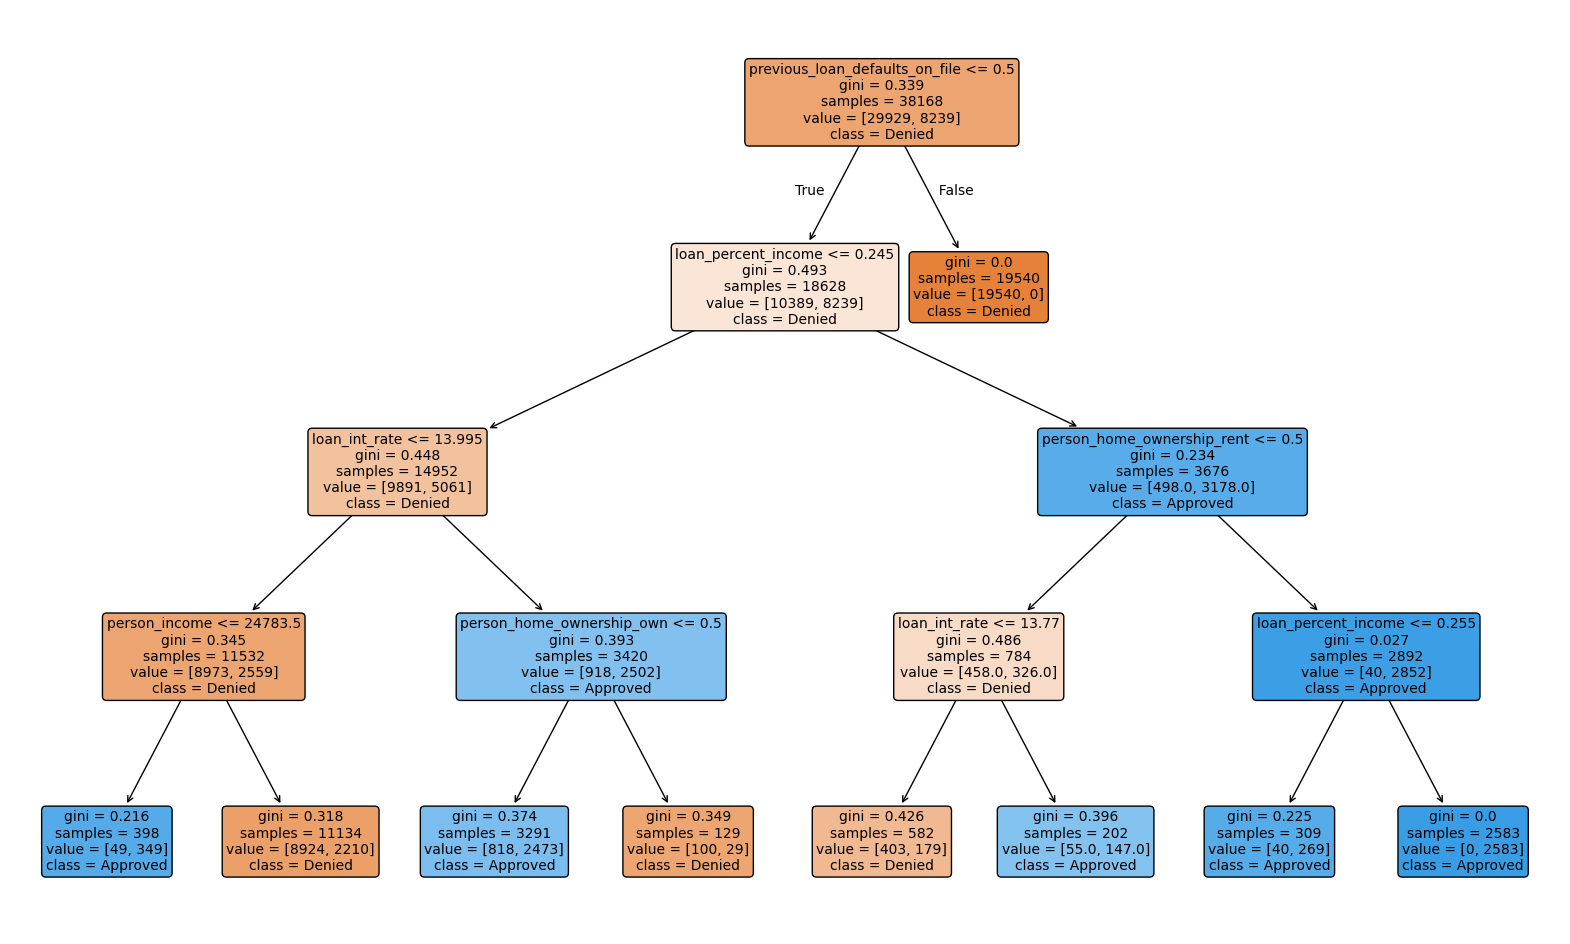

In [ ]:
plt.figure(figsize=(20,12))
plot_tree(Dtree, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=10)
plt.show()